In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

In [2]:
import pandas as pd
import numpy as np
from tensorflow.keras import utils # utils.to_categorical()
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt

# 로지스틱회귀분석(이진분류)
## 1. 데이터 셋 생성 및 전처리

In [3]:
# 1. csv 파일을 데이터프레임으로 읽어오기(결측치처리, 타겟변수 균형확인) => 넘파이 배열로 변환 => 데이터분할
df = pd.read_csv('data/pima-indians-diabetes.csv', comment='#', header=None)
# 1. 임신횟수
# 2. 2시간내 포도당 농도
# 3. 혈압
# 4. 피부접힘 두께
# 5. 인슐린수치
# 6. BMI체질량지수
# 7. 가족력
# 8. 나이
# 9. 당뇨병발병여부
df.sample()

,0,1,2,3,4,5,6,7,8
3,1,89,66,23,94,28.1,0.167,21,0


In [4]:
df.shape

(768, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       768 non-null    int64  
 1   1       768 non-null    int64  
 2   2       768 non-null    int64  
 3   3       768 non-null    int64  
 4   4       768 non-null    int64  
 5   5       768 non-null    float64
 6   6       768 non-null    float64
 7   7       768 non-null    int64  
 8   8       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.isna().sum() # 열별 결측치 갯수

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64

In [7]:
# 타겟변수의 균형 확인
df[8].value_counts()/len(df)

0    0.651042
1    0.348958
Name: 8, dtype: float64

In [8]:
# np.array(df)
dataset = df.values
dataset = df.to_numpy()

In [9]:
# 2. csv파일을 넘파이배열로 읽어오기 => 데이터 분할
    # np.loadtxt()
dataset = np.loadtxt('data/pima-indians-diabetes.csv',
                     encoding='utf-8',
                     delimiter=',',
                     # comments='#'
                     )
dataset.shape

(768, 9)

In [10]:
# 데이터 분할 : 학습데이터셋(모델학습용) + 시험데이터셋(모델평가용)
X_train = dataset[:620, :-1]
y_train = dataset[:620, -1]
X_test = dataset[620:, :-1]
y_test = dataset[620:, -1]
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((620, 8), (620,), (148, 8), (148,))

# 2. 모델 구성

In [11]:
model = Sequential()
# model.add(Dense(64,
#                 input_dim=8, # input_shape=(8,),
#                 activation='relu'))
model.add(Input(shape=(8, )))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=64, activation='elu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1, activation='sigmoid')) # 로지스틱회귀분석의 출력층 활성화함수
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                288       
                                                                 
 dense_1 (Dense)             (None, 64)                2112      
                                                                 
 dense_2 (Dense)             (None, 16)                1040      
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 3,457
Trainable params: 3,457
Non-trainable params: 0
_________________________________________________________________


# 3. 학습과정 설정

In [12]:
# model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['binary_accuracy'])
# accuracy가 자동적으로 binary_accuracy 적용
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 4. 학습

In [13]:
%%time
hist = model.fit(X_train, y_train, #훈련(학습)데이터셋
                 epochs=200,
                 batch_size=310,
                 # validation_data=(X_val, y_val) 검증데이터셋
                 validation_split=0.1, # 검증데이터비율(훈련데이터셋에서 10%는 검증데이터셋으로)
                 verbose=0) # 학습과정 로그 출력 안 함

CPU times: total: 10.9 s
Wall time: 9.13 s


## 5. 모델 평가하기
- 학습과정 시각화하여 살펴보기
- 평가(시험데이터셋)
- 교차표(혼동매트릭스, 성능평가지표) 그리기

In [14]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

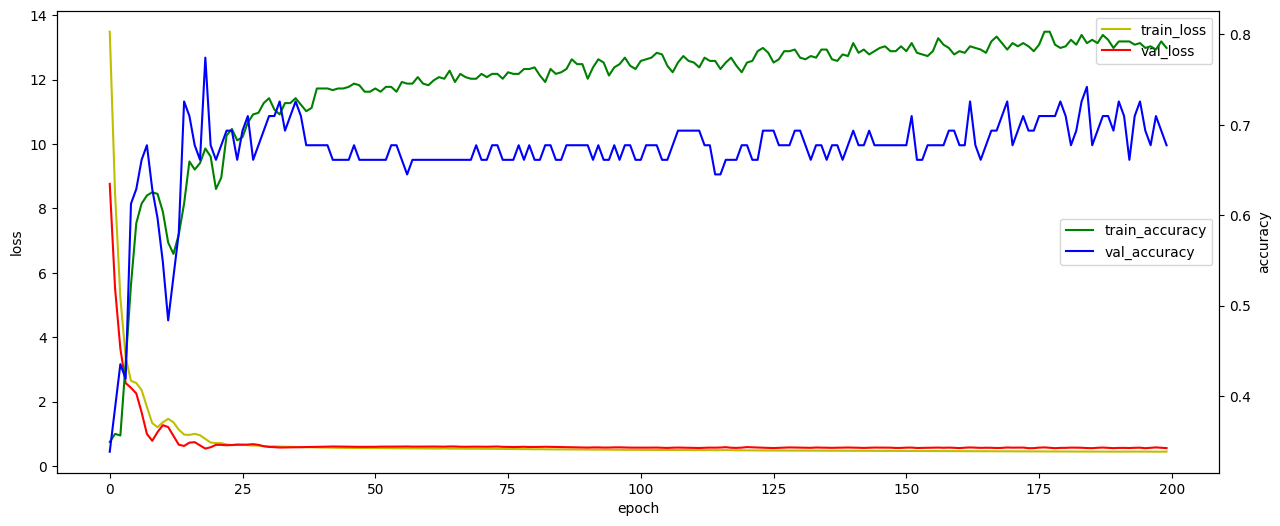

In [15]:
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')
plt.show()

In [16]:
# 모델 평가(X)
model.evaluate(X_train, y_train,
              # batch_size=310
              )

20/20 [==============================] - 0s 2ms/step - loss: 0.4541 - accuracy: 0.7823


[0.4541409909725189, 0.7822580933570862]

In [17]:
# 모델 평가(O)
loss, accuracy = model.evaluate(X_test, y_test)
print(f'정확도 : {accuracy*100:.2f}%')

5/5 [==============================] - 0s 2ms/step - loss: 0.6174 - accuracy: 0.6824
정확도 : 68.24%


In [18]:
# 교차표(혼동행렬, 성능평가지표)
y_hat = (model.predict(X_test)>0.5).astype(int)
# y_test : 1차원
# y_hat : 2차원

5/5 [==============================] - 0s 3ms/step


In [19]:
TN=0; FP=0; FN=0; TP=0
for y, h in zip(y_test, y_hat.reshape(-1)):
    # print(y, h)
      if y==0 and h==0:
          TN += 1
      elif y==0 and h==1:
        FP += 1
      elif y ==1 and h==0:
        FN += 1
      else:
        TP += 1
print(TN, FP)
print(FN, TP)

77 19
28 24


In [20]:
ctab = pd.crosstab(y_test, # 실제값
            y_hat.reshape(-1))
ctab.index.name = '실제값'
ctab.columns.name = '예측값'
pd.crosstab(y_test.astype(int),
           y_hat.reshape(-1),
           rownames=['실제값'],
           colnames=['예측값']) # 결과가 데이터프레임

예측값,0,1
실제값,,
0,77,19
1,28,24


In [21]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat) # 결과가 numpy배열인 혼동행렬

array([[77, 19],
       [28, 24]], dtype=int64)

In [22]:
precision = 26 / (15+26)
recall = 26 / (26+26)
print('recall :', recall)
print('prcision :', precision)

recall : 0.5
prcision : 0.6341463414634146


## 6. 모델 사용(예측, 저장)

In [23]:
# 모델 저장
from tensorflow.keras.models import save_model, load_model
model.save('model/05_pima.h5')
save_model(model, 'model/05_pima.h5')

In [24]:
# 저장한 모델 load
model2 = load_model('model/05_pima.h5')

In [25]:
X_test[0]

array([  2.   , 112.   ,  86.   ,  42.   , 160.   ,  38.4  ,   0.246,
        28.   ])

In [26]:
# 예측하기
(model.predict([[2, 112, 86, 42, 160, 38.4, 0.246, 28]])>0.5).astype(int)[0,0]

1/1 [==============================] - 0s 39ms/step


1

In [27]:
(model.predict([[2, 112, 86, 42, 160, 38.4, 0.246, 28],
               [6,148,72,35,0,33.6,0.627,50]
               ])>0.5).astype(int)

1/1 [==============================] - 0s 42ms/step


array([[1],
       [0]])

# 분류분석
- 1. 데이터 생성 및 전처리 : 훈련셋600, 검증셋100, 테스트셋68로 분리. 타겟변수의 원핫인코딩
- 2. 모델 생성(input8, output1) - 출력층의 활성화함수 softmax
- 3. 모델학습과정 loss='categorical_crossentropy' metrics=['accuracy']
- 4. 모델학습 validation_data = (X_val, y_val)
- 5. 모델학습평가
- 6. 모델사용
    model.predict(input_data).argmax()
    
## 1. 데이터셋 생성 및 전처리

In [37]:
df = pd.read_csv('data/pima-indians-diabetes.csv', comment='#', header=None)
dataset = df.values

In [38]:
# 훈련셋600, 검증셋100, 테스트셋68
X_train = dataset[:600, :-1]
y_train = dataset[:600, -1]
X_val   = dataset[600:700, :-1]
y_val   = dataset[600:700, -1]
X_test  = dataset[700:, :-1]
y_test  = dataset[700:, -1]
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((600, 8), (600,), (100, 8), (100,), (68, 8), (68,))

In [39]:
# 원핫인코딩 ( 0 : 1 0 / 1: 0 1)
Y_train = utils.to_categorical(y_train, num_classes=2) # pd.get_dummies(y_train).values
Y_val   = utils.to_categorical(y_val, 2)
Y_test  = utils.to_categorical(y_test)
X_train.shape, Y_train.shape, X_val.shape, Y_val.shape, X_test.shape, Y_test.shape

((600, 8), (600, 2), (100, 8), (100, 2), (68, 8), (68, 2))

In [40]:
print('원데이터 :', y_train[:3])
print('원핫인코딩 데이터 :\n', Y_train[:3])

원데이터 : [1. 0. 1.]
원핫인코딩 데이터 :
 [[0. 1.]
 [1. 0.]
 [0. 1.]]


In [41]:
model = Sequential()
model.add(Input(shape=(8,)))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=64, activation='elu'))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=2, activation='softmax')) # 분류분석의 출력층 활성화함수
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 32)                288       
                                                                 
 dense_9 (Dense)             (None, 64)                2112      
                                                                 
 dense_10 (Dense)            (None, 16)                1040      
                                                                 
 dense_11 (Dense)            (None, 2)                 34        
                                                                 
Total params: 3,474
Trainable params: 3,474
Non-trainable params: 0
_________________________________________________________________


## 3. 학습과정 설정

In [42]:
model.compile(loss='categorical_crossentropy',
             optimizer='nadam',
             metrics=['accuracy'])

## 4. 모델 학습

In [43]:
hist = model.fit(X_train, Y_train,
                epochs=200,
                validation_data=(X_val, Y_val),
                verbose=1)

Epoch 1/200
19/19 [==============================] - 1s 10ms/step - loss: 8.8036 - accuracy: 0.4833 - val_loss: 2.3683 - val_accuracy: 0.5100
Epoch 2/200
19/19 [==============================] - 0s 3ms/step - loss: 2.0378 - accuracy: 0.5883 - val_loss: 2.7393 - val_accuracy: 0.6600
Epoch 3/200
19/19 [==============================] - 0s 3ms/step - loss: 1.8568 - accuracy: 0.6200 - val_loss: 1.5931 - val_accuracy: 0.4900
Epoch 4/200
19/19 [==============================] - 0s 3ms/step - loss: 1.5459 - accuracy: 0.6167 - val_loss: 1.2754 - val_accuracy: 0.5000
Epoch 5/200
19/19 [==============================] - 0s 3ms/step - loss: 1.9660 - accuracy: 0.5900 - val_loss: 2.4060 - val_accuracy: 0.6500
Epoch 6/200
19/19 [==============================] - 0s 3ms/step - loss: 1.3084 - accuracy: 0.6700 - val_loss: 1.1792 - val_accuracy: 0.6900
Epoch 7/200
19/19 [==============================] - 0s 3ms/step - loss: 1.4090 - accuracy: 0.6383 - val_loss: 2.8209 - val_accuracy: 0.6700
Epoch 8/200


Epoch 59/200
19/19 [==============================] - 0s 3ms/step - loss: 0.6361 - accuracy: 0.7450 - val_loss: 1.2407 - val_accuracy: 0.4900
Epoch 60/200
19/19 [==============================] - 0s 3ms/step - loss: 0.8000 - accuracy: 0.7183 - val_loss: 0.7420 - val_accuracy: 0.7100
Epoch 61/200
19/19 [==============================] - 0s 3ms/step - loss: 0.6365 - accuracy: 0.7583 - val_loss: 0.6493 - val_accuracy: 0.7300
Epoch 62/200
19/19 [==============================] - 0s 3ms/step - loss: 0.5970 - accuracy: 0.7533 - val_loss: 0.7358 - val_accuracy: 0.7200
Epoch 63/200
19/19 [==============================] - 0s 3ms/step - loss: 0.5133 - accuracy: 0.7483 - val_loss: 0.7741 - val_accuracy: 0.7100
Epoch 64/200
19/19 [==============================] - 0s 3ms/step - loss: 0.6098 - accuracy: 0.7617 - val_loss: 0.6010 - val_accuracy: 0.7500
Epoch 65/200
19/19 [==============================] - 0s 3ms/step - loss: 0.5557 - accuracy: 0.7667 - val_loss: 1.3157 - val_accuracy: 0.6700
Epoch 

19/19 [==============================] - 0s 3ms/step - loss: 0.5503 - accuracy: 0.7567 - val_loss: 1.0134 - val_accuracy: 0.6200
Epoch 117/200
19/19 [==============================] - 0s 3ms/step - loss: 0.5091 - accuracy: 0.7800 - val_loss: 0.7854 - val_accuracy: 0.6900
Epoch 118/200
19/19 [==============================] - 0s 3ms/step - loss: 0.5040 - accuracy: 0.7717 - val_loss: 1.0393 - val_accuracy: 0.6800
Epoch 119/200
19/19 [==============================] - 0s 4ms/step - loss: 0.5121 - accuracy: 0.7800 - val_loss: 0.6965 - val_accuracy: 0.7300
Epoch 120/200
19/19 [==============================] - 0s 6ms/step - loss: 0.4595 - accuracy: 0.7950 - val_loss: 1.2043 - val_accuracy: 0.6800
Epoch 121/200
19/19 [==============================] - 0s 4ms/step - loss: 0.5536 - accuracy: 0.7800 - val_loss: 0.8517 - val_accuracy: 0.6900
Epoch 122/200
19/19 [==============================] - 0s 3ms/step - loss: 0.5319 - accuracy: 0.7767 - val_loss: 0.7173 - val_accuracy: 0.7200
Epoch 123/200

19/19 [==============================] - 0s 3ms/step - loss: 0.4599 - accuracy: 0.7917 - val_loss: 0.7343 - val_accuracy: 0.6900
Epoch 174/200
19/19 [==============================] - 0s 3ms/step - loss: 0.4358 - accuracy: 0.8067 - val_loss: 0.6635 - val_accuracy: 0.7100
Epoch 175/200
19/19 [==============================] - 0s 3ms/step - loss: 0.4453 - accuracy: 0.7750 - val_loss: 0.8987 - val_accuracy: 0.6300
Epoch 176/200
19/19 [==============================] - 0s 3ms/step - loss: 0.4475 - accuracy: 0.8083 - val_loss: 0.6648 - val_accuracy: 0.7600
Epoch 177/200
19/19 [==============================] - 0s 3ms/step - loss: 0.4424 - accuracy: 0.7983 - val_loss: 0.7311 - val_accuracy: 0.6900
Epoch 178/200
19/19 [==============================] - 0s 3ms/step - loss: 0.3946 - accuracy: 0.8283 - val_loss: 0.8532 - val_accuracy: 0.6900
Epoch 179/200
19/19 [==============================] - 0s 3ms/step - loss: 0.4170 - accuracy: 0.8083 - val_loss: 0.7414 - val_accuracy: 0.7100
Epoch 180/200

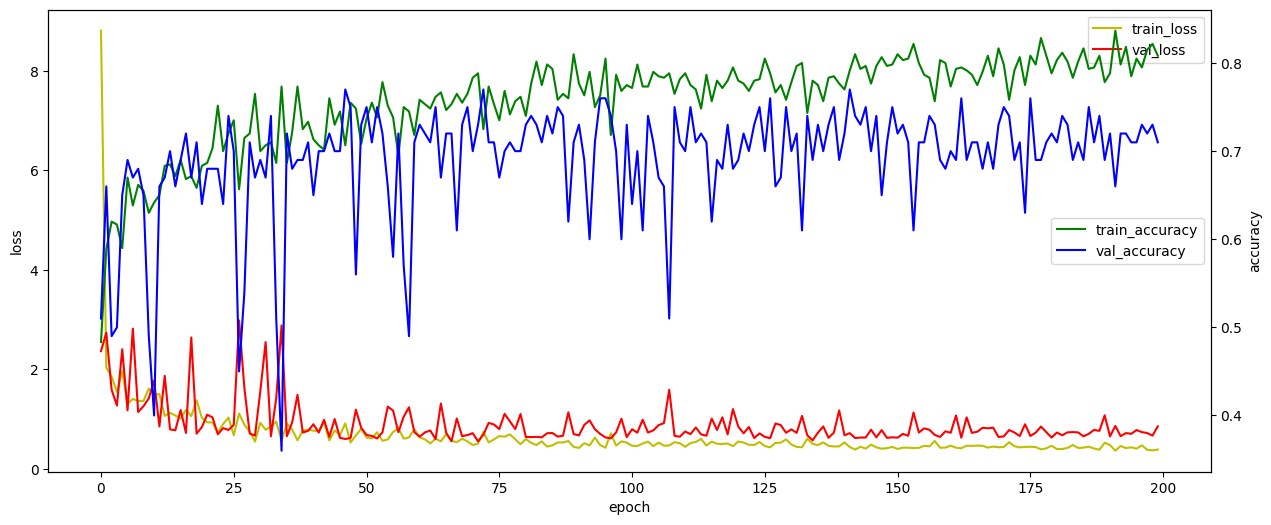

In [44]:
fig, loss_ax = plt.subplots(figsize=(15,6))
loss_ax.plot(hist.history['loss'], 'y', label='train_loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val_loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val_accuracy')

acc_ax.set_ylabel('accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')
plt.show()

## 5.모델평가

In [58]:
# 모델 평가
loss, accuracy = model.evaluate(X_test, Y_test)
accuracy

3/3 [==============================] - 0s 2ms/step - loss: 0.9295 - accuracy: 0.6618


0.6617646813392639

In [59]:
# 혼동행렬==교차표를 위한 y_test의 예측값
y_hat = model.predict(X_test).argmax(axis=1) # 예측값 / 실제값 y_test
y_hat.shape, y_test.shape

3/3 [==============================] - 0s 2ms/step


((68,), (68,))

In [60]:
# 교차표(데이터 프레임)
pd.crosstab(y_test, y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1
실제값,,
0.0,40,1
1.0,22,5


In [54]:
# 혼동행렬(numpy 배열)
confusion_matrix(y_test, y_hat)

array([[40,  1],
       [22,  5]], dtype=int64)

# 6. 모델 사용(예측)

In [55]:
X_test[0]

array([  2.   , 122.   ,  76.   ,  27.   , 200.   ,  35.9  ,   0.483,
        26.   ])

In [57]:
model.predict([[2, 122, 76, 27, 200, 35.9, 0.483,26]]).argmax(axis=1)

1/1 [==============================] - 0s 44ms/step


array([0], dtype=int64)